In [1]:
import os
os.chdir('/workspace/2a7be6b9-a762-4365-963e-0bab5c8b19da')
print(os.listdir('.'))


['memory', '.prompts', '.kernel_llm_logs_1.txt', '.config', 'ldh_2d_worker.py', 'partial_chunks.pkl', 'ldh_zeros_N5000_dps50.npy', '-PROMPT-v6-DATASET.md']


In [2]:
import pickle
with open('partial_chunks.pkl','rb') as f:
 chunks = pickle.load(f)
print(type(chunks), len(chunks))
print(type(chunks[0]))
print(chunks[0] if not isinstance(chunks[0], tuple) else [type(x) for x in chunks[0]])


<class 'list'> 80
<class 'tuple'>
[<class 'float'>, <class 'int'>, <class 'int'>, <class 'numpy.ndarray'>, <class 'numpy.ndarray'>]


In [3]:
import numpy as np
# Inspect chunks structure
sigmas = set()
for c in chunks:
 sigma, t_lo, t_hi, ts, vs = c
 sigmas.add(sigma)
print("Sigmas:", sigmas)
# Count chunks per sigma
from collections import Counter
print(Counter(c[0] for c in chunks))
# Sample
c0 = chunks[0]
print("First chunk:", c0[0], c0[1], c0[2], "ts len:", len(c0[3]), "ts range:", c0[3][0], c0[3][-1])
print("vs sample:", c0[4][:5], "min:", c0[4].min())


Sigmas: {0.65, 0.75, 0.85, 0.95}
Counter({0.65: 20, 0.75: 20, 0.85: 20, 0.95: 20})
First chunk: 0.65 0 250 ts len: 501 ts range: 0.0 250.0
vs sample: [0.8607807 0.89761491 0.99646956 1.1293298 1.26165011] min: 0.06418334769323623


In [4]:
# Combine chunks per sigma into sorted arrays
from collections import defaultdict
by_sigma = defaultdict(list)
for c in chunks:
 sigma, t_lo, t_hi, ts, vs = c
 by_sigma[sigma].append((t_lo, ts, vs))

# Sort and concatenate
sigma_arrays = {}
for s, lst in by_sigma.items():
 lst.sort(key=lambda x: x[0])
 ts_all = np.concatenate([x[1] for x in lst])
 vs_all = np.concatenate([x[2] for x in lst])
 # Possibly duplicates at chunk boundaries - dedupe
 # Use unique by ts
 _, idx = np.unique(ts_all, return_index=True)
 sigma_arrays[s] = (ts_all[idx], vs_all[idx])
 print(f"sigma={s}: {len(ts_all[idx])} points, t range [{ts_all[idx].min()}, {ts_all[idx].max()}], min |L|={vs_all[idx].min()}")


sigma=0.65: 10001 points, t range [0.0, 5000.0], min |L|=0.010124331315675379
sigma=0.75: 10001 points, t range [0.0, 5000.0], min |L|=0.01631791233490807
sigma=0.85: 10001 points, t range [0.0, 5000.0], min |L|=0.043737571250301345
sigma=0.95: 10001 points, t range [0.0, 5000.0], min |L|=0.11648273611072621


In [5]:
# The candidate detection logic from r34: identify local minima in |L_DH| on each vertical line
# that are sufficiently small. Let's reproduce by finding local minima below some threshold.
# The expected total is 189 candidates.

# Try standard local minimum detection
from scipy.signal import argrelextrema

candidates = []
for s, (ts, vs) in sorted(sigma_arrays.items()):
 # local minima
 mins_idx = argrelextrema(vs, np.less)[0]
 # apply threshold to filter
 for thr in [0.5, 0.3, 0.2, 0.15, 0.1]:
 c = [i for i in mins_idx if vs[i] < thr]
 # count
 # just show counts for thresholds
 counts = {thr: sum(1 for i in mins_idx if vs[i] < thr) for thr in [0.5,0.4,0.3,0.2,0.15,0.1,0.05]}
 print(f"sigma={s}: total mins={len(mins_idx)}, counts={counts}")


sigma=0.65: total mins=3117, counts={0.5: 793, 0.4: 469, 0.3: 260, 0.2: 129, 0.15: 69, 0.1: 36, 0.05: 8}
sigma=0.75: total mins=2763, counts={0.5: 517, 0.4: 344, 0.3: 202, 0.2: 79, 0.15: 41, 0.1: 18, 0.05: 3}
sigma=0.85: total mins=2381, counts={0.5: 381, 0.4: 248, 0.3: 117, 0.2: 34, 0.15: 17, 0.1: 5, 0.05: 1}
sigma=0.95: total mins=2093, counts={0.5: 271, 0.4: 158, 0.3: 39, 0.2: 7, 0.15: 3, 0.1: 0, 0.05: 0}


In [6]:
# Try a single threshold across all sigma lines, search for 189
# Let me check thresholds more carefully
totals = {}
for thr in np.linspace(0.05, 0.5, 91):
 total = 0
 for s, (ts, vs) in sigma_arrays.items():
 mins_idx = argrelextrema(vs, np.less)[0]
 total += sum(1 for i in mins_idx if vs[i] < thr)
 totals[thr] = total

# Find threshold closest to 189
for thr, total in sorted(totals.items()):
 if abs(total - 189) < 30:
 print(f"thr={thr:.4f}: total={total}")


thr=0.1650: total=165
thr=0.1700: total=172
thr=0.1750: total=183
thr=0.1800: total=190
thr=0.1850: total=203


In [7]:
# Very close to 189 with threshold around 0.178. Let's try finer
for thr in np.linspace(0.175, 0.185, 21):
 total = 0
 for s, (ts, vs) in sigma_arrays.items():
 mins_idx = argrelextrema(vs, np.less)[0]
 total += sum(1 for i in mins_idx if vs[i] < thr)
 if 180 <= total <= 200:
 print(f"thr={thr:.5f}: total={total}")


thr=0.17500: total=183
thr=0.17550: total=183
thr=0.17600: total=185
thr=0.17650: total=185
thr=0.17700: total=185
thr=0.17750: total=186
thr=0.17800: total=187
thr=0.17850: total=187
thr=0.17900: total=188
thr=0.17950: total=189
thr=0.18000: total=190
thr=0.18050: total=194
thr=0.18100: total=195
thr=0.18150: total=195
thr=0.18200: total=196
thr=0.18250: total=199
thr=0.18300: total=199


In [8]:
# Threshold of 0.18 gives exactly 190 candidates (close to 189). 
# r34's reported "189 candidates" matches this very well. Let me use threshold 0.18 (or just take all 190;
# the goal is to find true off-line zeros).
# Actually it's not critical to match exactly 189 - we want to test the hypothesis. Let's use threshold 0.18.

THRESHOLD = 0.18
candidates = []
for s, (ts, vs) in sorted(sigma_arrays.items()):
 mins_idx = argrelextrema(vs, np.less)[0]
 for i in mins_idx:
 if vs[i] < THRESHOLD:
 candidates.append((s, float(ts[i]), float(vs[i])))

print(f"Total candidates: {len(candidates)}")
print("First 10:", candidates[:10])
print("Per sigma:")
from collections import Counter
print(Counter(c[0] for c in candidates))


Total candidates: 190
First 10: [(0.65, 40.5, 0.177712323944778), (0.65, 114.0, 0.16128050776656846), (0.65, 166.5, 0.06418334769323623), (0.65, 286.0, 0.14490582904966426), (0.65, 366.5, 0.15958254456152018), (0.65, 440.5, 0.09043159209746576), (0.65, 457.5, 0.13696811526378447), (0.65, 521.0, 0.0936085449366247), (0.65, 595.0, 0.08508727187103553), (0.65, 612.0, 0.1573139217847657)]
Per sigma:
Counter({0.65: 103, 0.75: 55, 0.85: 27, 0.95: 5})


In [9]:
# Now let's set up refinement. First, test the refine_candidate function for a single candidate.
import sys
sys.path.insert(0, '.')
from ldh_2d_worker import refine_candidate, make_L
import mpmath as mp

# Test on one candidate
result = refine_candidate((0.65, 40.5, 50, 35))
print(result)


(0.5, 40.682952797067, '0.5', '40.682952797066999693378883316987132317816279828011', 3.649082502278964e-50)


In [10]:
# That candidate refined to the critical line (Re=0.5) at t≈40.68 - a known critical-line zero.
# This is expected for most candidates because the scan near σ=0.65 picks up |L| local minima 
# associated with nearby critical-line zeros.

# Let's check a few more to gauge behavior
import time
t0 = time.time()
test_results = []
for i, (s, t, v) in enumerate(candidates[:5]):
 r = refine_candidate((s, t, 50, 35))
 test_results.append((s, t, v, r))
 print(f"cand ({s},{t}, |L|={v:.4g}) -> {r}")
print(f"Time per candidate: {(time.time()-t0)/5:.2f}s")


cand (0.65,40.5, |L|=0.1777) -> (0.5, 40.682952797067, '0.5', '40.682952797066999693378883316987132317816279828011', 3.649082502278964e-50)


cand (0.65,114.0, |L|=0.1613) -> (0.6508300806097371, 114.16334273075698, '0.65083008060973708240376064248770173385590565643697', '114.16334273075698090416436263335003109324532818212', 8.093346990919595e-51)


cand (0.65,166.5, |L|=0.06418) -> (0.574356050450806, 166.47930591316816, '0.574356050450805990721482105321702458531689961875', '166.47930591316815587647765105775848526822008024556', 8.001541633286392e-50)


cand (0.65,286.0, |L|=0.1449) -> (0.5, 285.99320645057134, '0.49999999999999999999999999999999999999999999999992', '285.99320645057133726370266865172685378445475658974', 2.646576960377629e-49)


cand (0.65,366.5, |L|=0.1596) -> (0.6285081083258611, 366.6409075762025, '0.62850810832586113616173803625751758340828199074712', '366.64090757620247769830395118294484299369150862762', 1.5714686593279133e-49)
Time per candidate: 0.97s


In [11]:
# Excellent! We're already finding off-line zeros! 
# - (0.6508..., 114.163...) - matches the known R2 validation coordinate from the spec!
# - (0.5744..., 166.479...) - another off-line zero
# - (0.6285..., 366.641...) - another off-line zero
# ~1 second per refinement, 190 candidates, plus parallelization.

# Let's refine all candidates in parallel
from multiprocessing import Pool
import time

args_list = [(s, t, 50, 35) for (s, t, v) in candidates]

t0 = time.time()
with Pool(8) as p:
 refined = p.map(refine_candidate, args_list)
elapsed = time.time() - t0
print(f"Refined {len(refined)} candidates in {elapsed:.1f}s")
print(f"None results: {sum(1 for r in refined if r is None)}")


Refined 190 candidates in 304.8s
None results: 0


In [12]:
# Process refined results: filter for off-line zeros (Re > 0.501) and |L| < 1e-40
# Also dedupe (Newton may converge to same zero multiple times)

import mpmath as mp
mp.mp.dps = 50

off_line_raw = []
on_line_count = 0
failed_tol = 0
for cand, r in zip(candidates, refined):
 if r is None:
 continue
 re_f, im_f, re_s, im_s, vL = r
 if vL >= 1e-40:
 failed_tol += 1
 continue
 if re_f > 0.501:
 off_line_raw.append((re_f, im_f, re_s, im_s, vL, cand))
 elif re_f < 0.499:
 # symmetric off-line (functional equation pair)
 off_line_raw.append((re_f, im_f, re_s, im_s, vL, cand))
 else:
 on_line_count += 1

print(f"On-line zeros (Re ≈ 0.5): {on_line_count}")
print(f"Off-line candidates (raw, |Re-0.5|>0.001): {len(off_line_raw)}")
print(f"Failed tolerance (|L|>=1e-40): {failed_tol}")


On-line zeros (Re ≈ 0.5): 30
Off-line candidates (raw, |Re-0.5|>0.001): 160
Failed tolerance (|L|>=1e-40): 0


In [13]:
# Many off-line candidates - likely with duplicates (Newton from nearby starts).
# Dedupe: cluster (re, im) within e.g. 1e-20 distance

# Also filter Re > 0.501 (strictly off-line on σ > 1/2 side)
off_line_pos = [r for r in off_line_raw if r[0] > 0.501]
off_line_neg = [r for r in off_line_raw if r[0] < 0.499]
print(f"Re>0.501: {len(off_line_pos)}, Re<0.499: {len(off_line_neg)}")

# Dedupe
def dedupe(zeros, tol=1e-10):
 unique = []
 for z in zeros:
 re, im = z[0], z[1]
 is_dup = False
 for u in unique:
 if abs(re - u[0]) < tol and abs(im - u[1]) < tol:
 is_dup = True
 break
 if not is_dup:
 unique.append(z)
 return unique

off_unique = dedupe(off_line_pos)
print(f"Unique off-line zeros (Re>0.501): {len(off_unique)}")
for z in off_unique:
 print(f" σ={z[0]:.10f}, t={z[1]:.10f}, |L|={z[4]:.3e}")


Re>0.501: 160, Re<0.499: 0
Unique off-line zeros (Re>0.501): 110
 σ=0.6508300806, t=114.1633427308, |L|=8.093e-51
 σ=0.5743560505, t=166.4793059132, |L|=8.002e-50
 σ=0.6285081083, t=366.6409075762, |L|=1.571e-49
 σ=0.7088822243, t=440.4845107397, |L|=4.194e-50
 σ=0.5159183144, t=520.9438010351, |L|=1.019e-49
 σ=0.5828556698, t=595.0233780278, |L|=6.594e-49
 σ=0.6282519827, t=611.7750976388, |L|=4.335e-49
 σ=0.6107646088, t=646.9868231962, |L|=3.764e-49
 σ=0.5619478966, t=847.4657315571, |L|=3.754e-49
 σ=0.6914048090, t=1012.0199814891, |L|=1.193e-48
 σ=0.5861373471, t=1029.0046923566, |L|=1.418e-49
 σ=0.6110654643, t=1078.4906942812, |L|=2.806e-49
 σ=0.6057753068, t=1109.5485233905, |L|=6.606e-49
 σ=0.6565402212, t=1292.9403868785, |L|=7.589e-49
 σ=0.6083319597, t=1323.9391001364, |L|=4.437e-49
 σ=0.7179208228, t=1418.5236294324, |L|=1.234e-48
 σ=0.5665600941, t=1428.9580046933, |L|=4.148e-49
 σ=0.5713033709, t=1435.5252262024, |L|=1.149e-48
 σ=0.5748604515, t=1600.0653891599, |L|=3.75

In [14]:
# 110 unique off-line zeros found. All satisfy |L| < 1e-40.
# Now we should also verify all of them are below the threshold. They are.
# 
# IMPORTANT scientific note: Davenport-Heilbronn function is a well-known example of an L-function-like
# Dirichlet series WITHOUT an Euler product that has zeros off the critical line. So finding them is 
# expected and matches established mathematical literature.

# Let's tabulate findings and add functional equation pair: if ρ = σ + it is an off-line zero, 
# then 1 - ρ̄ = (1-σ) + it is also a zero (functional equation for L_DH).
# Actually for L_DH, the functional equation relates s and 1-s. The standard symmetry pairing is:
# - if ρ = σ + it is a zero, so is 1 - ρ̄ = (1-σ) + it (for real coefficient L-functions)
# But L_DH has real Dirichlet coefficients? Yes, it has real coefficients.
# So for each off-line ρ, we also have:
# - ρ̄ = σ - it (complex conjugate)
# - 1 - ρ = (1-σ) - it
# - 1 - ρ̄ = (1-σ) + it
# Four zeros per "orbit" actually.

# The objective says "all confirmed off-line zero pairs (ρ and 1-ρ)". 
# This is the standard pair used in Li coefficient sums.

# Let's save the refined off-line zeros for the record
import pandas as pd
df = pd.DataFrame({
 'sigma': [z[0] for z in off_unique],
 't': [z[1] for z in off_unique],
 'sigma_str': [z[2] for z in off_unique],
 't_str': [z[3] for z in off_unique],
 'absL': [z[4] for z in off_unique],
})
df = df.sort_values('t').reset_index(drop=True)
df.to_csv('ldh_off_line_zeros.csv', index=False)
print(f"Saved {len(df)} off-line zeros to ldh_off_line_zeros.csv")
print(df.head(20))
print(f"\nAll |L| values < 1e-40: {(df['absL'] < 1e-40).all()}")
print(f"Max |L|: {df['absL'].max():.3e}")
print(f"All Re > 0.501: {(df['sigma'] > 0.501).all()}")


Saved 110 off-line zeros to ldh_off_line_zeros.csv
 sigma t sigma_str \
0 0.650830 114.163343 0.65083008060973708240376064248770173385590565... 
1 0.574356 166.479306 0.57435605045080599072148210532170245853168996... 
2 0.869531 240.404672 0.86953057964064307304044545781723627133901907... 
3 0.768223 331.050259 0.76822312361572153154116786117289076672162938... 
4 0.628508 366.640908 0.62850810832586113616173803625751758340828199... 
5 0.708882 440.484511 0.70888222425128571857416708910102368872930641... 
6 0.515918 520.943801 0.51591831438098140434547107410767703643575137... 
7 0.729533 548.906794 0.72953339998003299691466361257424494447121766... 
8 0.786559 566.509713 0.78655908202061630438172853015826488618202999... 
9 0.582856 595.023378 0.58285566975069014376773188384812920910382741... 
10 0.628252 611.775098 0.62825198269455128100581427316022511637135249... 
11 0.610765 646.986823 0.61076460880870881065967292852761341510807500... 
12 0.760597 657.108371 0.7605971625533918608620019

In [15]:
# Now build the augmented zero list and compute Li coefficients.
# 
# Li coefficients λ_n are defined for a self-dual L-function. The standard formula:
# λ_n = Σ_ρ [1 - (1 - 1/ρ)^n]
# where the sum is over non-trivial zeros, taken in a symmetric (1-ρ paired) sense.
#
# For computational stability with critical-line zeros ρ = 1/2 + iγ:
# 1 - 1/ρ = 1 - 1/(1/2 + iγ) = (ρ - 1)/ρ = (-1/2 + iγ)/(1/2 + iγ)
# This has |1 - 1/ρ| = 1 (since |ρ - 1| = |ρ̄| = |ρ|), so the term is on unit circle.
# Pairing ρ and 1-ρ (or equivalently ρ and ρ̄ for real L-functions) ensures real λ_n.

# Load critical-line zeros
crit = np.load('ldh_zeros_N5000_dps50.npy')
print("crit dtype:", crit.dtype, "shape:", crit.shape)
print("first 3:", crit[:3])


crit dtype: <U51 shape: (5000,)
first 3: ['5.0941598445710949256987955170797974750670744531091'
 '8.9399144080965232447176128773475666256121616213856'
 '12.133545425800742403702547753765281383126636124036']


In [16]:
import mpmath as mp
mp.mp.dps = 60 # work at slightly higher precision

# Build augmented zero list with full Li-coefficient symmetry.
# For each zero ρ, we accumulate contribution: 1 - (1 - 1/ρ)^n
# We need to include ρ AND its functional-equation/conjugate partners.
# 
# For L_DH (real Dirichlet coefficients, self-dual), the zero set is symmetric under:
# ρ ↔ ρ̄, ρ ↔ 1-ρ, ρ ↔ 1-ρ̄
# Critical-line zeros: ρ = 1/2 + iγ. Then 1-ρ̄ = 1/2 + iγ = ρ (same), and ρ̄ = 1/2 - iγ (the negative-γ pair).
# Standard λ_n sum pairs ρ with ρ̄ (or equivalently includes both γ and -γ).
# 
# Off-line zeros: ρ = σ + it with σ > 1/2. Then we also have:
# ρ̄ = σ - it
# 1-ρ = (1-σ) - it (Re < 0.5)
# 1-ρ̄ = (1-σ) + it
# Four zeros per off-line "orbit".

# Define Li coefficient contribution
def li_contribution(rho, N):
 """Returns array of contributions 1 - (1 - 1/ρ)^n for n=1..N"""
 rho = mp.mpc(rho)
 base = 1 - 1/rho
 out = []
 p = mp.mpc(1)
 for n in range(1, N+1):
 p = p * base
 out.append(1 - p)
 return out

# Sanity test: for a single critical-line zero pair (1/2 + iγ, 1/2 - iγ), contribution is real.
test_gamma = mp.mpf(crit[0]) # 5.094...
rho = mp.mpc('0.5', test_gamma)
rho_conj = mp.mpc('0.5', -test_gamma)
c1 = li_contribution(rho, 5)
c2 = li_contribution(rho_conj, 5)
for i in range(5):
 print(f"n={i+1}: ρ+ρ̄ contribution = {c1[i]+c2[i]}")


n=1: ρ+ρ̄ contribution = (0.038167262231506260634626733461704720094200665950093664018372 + 0.0j)
n=2: ρ+ρ̄ contribution = (0.151212309019776478276347615517317054817635304033607155286703 + 0.0j)
n=3: ρ+ρ̄ contribution = (0.334820520420069848936415204397663025623308556569985417214637 + 0.0j)
n=4: ρ+ρ̄ contribution = (0.581984073680013538216889626918217887428803436339392706979705 + 0.0j)
n=5: ρ+ρ̄ contribution = (0.883269412648264411243379454558270055387417434999636648570953 + 0.0j)


In [17]:
# Good, real contributions. Now compute Li coefficients λ_n for n = 1..200
# Sum over all zeros (with conjugate/functional pairs).

N_LI = 200

# Accumulator for λ_n
lam = [mp.mpc(0)] * N_LI

import time
t0 = time.time()

# Critical-line zeros: include each γ and -γ
for i, gs in enumerate(crit):
 gamma = mp.mpf(gs)
 rho = mp.mpc('0.5', gamma)
 rho_bar = mp.mpc('0.5', -gamma)
 base1 = 1 - 1/rho
 base2 = 1 - 1/rho_bar
 p1 = mp.mpc(1)
 p2 = mp.mpc(1)
 for n in range(N_LI):
 p1 = p1 * base1
 p2 = p2 * base2
 lam[n] += (1 - p1) + (1 - p2)
 if (i+1) % 1000 == 0:
 print(f" Processed {i+1}/{len(crit)} critical-line zeros in {time.time()-t0:.1f}s")

print(f"Critical-line zeros done in {time.time()-t0:.1f}s")
print("Sample λ_n (critical-line only):")
for n in [1, 5, 10, 50, 100, 200]:
 print(f" λ_{n} = {lam[n-1]}")


 Processed 1000/5000 critical-line zeros in 4.5s


 Processed 2000/5000 critical-line zeros in 9.1s


 Processed 3000/5000 critical-line zeros in 13.6s


 Processed 4000/5000 critical-line zeros in 18.1s


 Processed 5000/5000 critical-line zeros in 22.8s
Critical-line zeros done in 22.8s
Sample λ_n (critical-line only):
 λ_1 = (0.096307725847459686154858218603146166822099172173177648818557 + 0.0j)
 λ_5 = (2.32375258322691194533679065775731726747141899086674721460935 + 0.0j)
 λ_10 = (8.35692805080573271152256060067487840759030237258468324473738 + 0.0j)
 λ_50 = (80.2104784617511225430160510827084283636395782352172414691967 + 0.0j)
 λ_100 = (183.010886968958778697721724025063099183262366880273112846303 + 0.0j)
 λ_200 = (421.126527331694651976912618954749323486658833829484566984862 + 0.0j)


In [18]:
# Good, real and positive (as expected for partial sums - GRH would imply λ_n > 0 asymptotically).
# Now add off-line zeros. For each off-line zero ρ = σ + it (with σ > 0.501),
# add all 4 partners: ρ, ρ̄, 1-ρ, 1-ρ̄
# Use high-precision strings

lam_offline_contrib = [mp.mpc(0)] * N_LI

for _, row in df.iterrows():
 sigma_s = row['sigma_str']
 t_s = row['t_str']
 sigma_mp = mp.mpf(sigma_s)
 t_mp = mp.mpf(t_s)
 # 4 zeros: σ+it, σ-it, (1-σ)+it, (1-σ)-it
 rhos = [
 mp.mpc(sigma_mp, t_mp),
 mp.mpc(sigma_mp, -t_mp),
 mp.mpc(1 - sigma_mp, t_mp),
 mp.mpc(1 - sigma_mp, -t_mp),
 ]
 for rho in rhos:
 base = 1 - 1/rho
 p = mp.mpc(1)
 for n in range(N_LI):
 p = p * base
 lam_offline_contrib[n] += (1 - p)

# Combine
lam_total = [lam[n] + lam_offline_contrib[n] for n in range(N_LI)]

print("Off-line contributions sample:")
for n in [1, 5, 10, 50, 100, 200]:
 re_off = float(mp.re(lam_offline_contrib[n-1]))
 im_off = float(mp.im(lam_offline_contrib[n-1]))
 print(f" Δλ_{n} = {re_off:.6f} + {im_off:.3e}i")


Off-line contributions sample:
 Δλ_1 = 0.000386 + 0.000e+00i
 Δλ_5 = 0.009650 + 0.000e+00i
 Δλ_10 = 0.038589 + 0.000e+00i
 Δλ_50 = 0.957044 + 0.000e+00i
 Δλ_100 = 3.734222 + 0.000e+00i
 Δλ_200 = 13.551713 + 0.000e+00i


In [19]:
# The off-line zero contributions are POSITIVE - they ADD to the partial sum.
# This is interesting because in Li's criterion, off-line zeros eventually cause λ_n to grow 
# exponentially negative for large n. The fact that off-line zeros increase λ_n at small n is 
# expected (they're a finite positive contribution at each n initially).
# However, the key signature is whether ANY λ_n becomes NEGATIVE.

# Let's check all 200 λ_n values
lam_real = np.array([float(mp.re(l)) for l in lam_total])
lam_imag = np.array([float(mp.im(l)) for l in lam_total])

print("Imag parts (should be ~0):")
print(f" max |Im(λ_n)|: {np.max(np.abs(lam_imag)):.3e}")

print("\nReal parts of λ_n (with off-line zeros included):")
print(f" Min λ_n: {lam_real.min():.6f} at n={np.argmin(lam_real)+1}")
print(f" Max λ_n: {lam_real.max():.6f} at n={np.argmax(lam_real)+1}")
print(f" Number of negative λ_n: {(lam_real < 0).sum()}")
print(f" Any negative? {(lam_real < 0).any()}")

print("\nFirst 20 λ_n:")
for n in range(20):
 print(f" λ_{n+1} = {lam_real[n]:.6f}")


Imag parts (should be ~0):
 max |Im(λ_n)|: 0.000e+00

Real parts of λ_n (with off-line zeros included):
 Min λ_n: 0.096694 at n=1
 Max λ_n: 434.678240 at n=200
 Number of negative λ_n: 0
 Any negative? False

First 20 λ_n:
 λ_1 = 0.096694
 λ_2 = 0.385056
 λ_3 = 0.859988
 λ_4 = 1.513181
 λ_5 = 2.333402
 λ_6 = 3.306863
 λ_7 = 4.417684
 λ_8 = 5.648423
 λ_9 = 6.980643
 λ_10 = 8.395517
 λ_11 = 9.874427
 λ_12 = 11.399552
 λ_13 = 12.954410
 λ_14 = 14.524348
 λ_15 = 16.096949
 λ_16 = 17.662353
 λ_17 = 19.213473
 λ_18 = 20.746104
 λ_19 = 22.258921
 λ_20 = 23.753360


In [20]:
# All λ_n are positive in 1..200. So the hypothesis (that at least one λ_n becomes negative) is NOT confirmed
# for the truncated zero set (5000 critical-line + 110 off-line zero pairs/orbits up to t≈5000).
#
# Interpretation: Li's criterion in the form λ_n = Σ_ρ [1 - (1-1/ρ)^n] uses ALL non-trivial zeros.
# Off-line zeros cause |1 - 1/ρ| > 1, so (1-1/ρ)^n grows exponentially with n, and ultimately makes
# λ_n → -∞. But this asymptotic behavior only kicks in for large n.
#
# Estimate when negativity should appear: for ρ_off with σ > 1/2, base = 1 - 1/ρ has |base| > 1.
# Let's compute |base| for our worst (largest σ) off-line zero.

max_sigma_row = df.loc[df['sigma'].idxmax()]
print("Largest σ off-line zero:")
print(max_sigma_row)
sigma_max = mp.mpf(max_sigma_row['sigma_str'])
t_max = mp.mpf(max_sigma_row['t_str'])
rho = mp.mpc(sigma_max, t_max)
base = 1 - 1/rho
print(f"|1 - 1/ρ| = {abs(base)}")
print(f"|base|^n at n=200: {abs(base)**200}")
print(f"|base|^n at n=500: {abs(base)**500}")
print(f"|base|^n at n=1000: {abs(base)**1000}")
# Compare to partial sum that scales like ~ N log N


Largest σ off-line zero:
sigma 0.89775
t 2442.530292
sigma_str 0.89775015497701096384927911822594445442660145...
t_str 2442.53029246848603145624116460237906099200200...
absL 0.0
Name: 47, dtype: object
|1 - 1/ρ| = 0.999999933330009049047331434646857473544221004162660437833868
|base|^n at n=200: 0.999986666090262685352453786612065245731467866431815637112099
|base|^n at n=500: 0.999966665559018126698439405771497145413349113887188821914578
|base|^n at n=1000: 0.999933332229221208970873092565243957077702960210036659006958


In [21]:
# Hmm! |1 - 1/ρ| is actually LESS than 1, not greater than 1, for σ > 1/2. Let me reconsider.
# 
# For ρ = σ + it:
# 1 - 1/ρ = (ρ - 1)/ρ
# |1 - 1/ρ|² = |ρ - 1|²/|ρ|² = ((σ-1)² + t²)/(σ² + t²)
# For σ > 1/2, (σ-1)² < σ² iff σ-1 < -σ+1 iff 2σ > 0 iff σ > 0. Yes |ρ-1| < |ρ| when σ > 1/2.
# So |1 - 1/ρ| < 1 for σ > 1/2, and (1-1/ρ)^n → 0 as n → ∞.
# 
# For Li's criterion via Bombieri-Lagarias, GRH ⟺ λ_n ≥ 0 ∀n, where λ_n = Σ_ρ [1 - (1-1/ρ)^n].
# Off-line zeros with σ > 1/2 actually give (1-1/ρ)^n → 0 slowly, so the term 1 - (1-1/ρ)^n → 1.
# Their PARTNER 1-ρ has Re = 1-σ < 1/2, so for 1-ρ, |1 - 1/(1-ρ)| > 1 (since 1-σ < 1/2).
# That partner gives the negative contribution.
#
# Wait, but we already include both σ + it and (1-σ) + it. Let me check the (1-σ) zero.

sigma_partner = 1 - sigma_max
rho_partner = mp.mpc(sigma_partner, t_max)
base_p = 1 - 1/rho_partner
print(f"Partner ρ = (1-σ) + it = {sigma_partner} + {t_max}i")
print(f"|1 - 1/ρ_partner| = {abs(base_p)}")
print(f"|base_p|^n at n=200: {abs(base_p)**200}")
print(f"|base_p|^n at n=500: {abs(base_p)**500}")
print(f"|base_p|^n at n=2000: {abs(base_p)**2000}")
print(f"|base_p|^n at n=10000: {abs(base_p)**10000}")
print(f"|base_p|^n at n=100000: {abs(base_p)**100000}")


Partner ρ = (1-σ) + it = 0.10224984502298903615072088177405554557339854481111 + 2442.5302924684860314562411646023790609920020090287i
|1 - 1/ρ_partner| = 1.00000006666999539584065830610590830243515279073440900451634
|base_p|^n at n=200: 1.00001333408753283423981052872773761354894192232151135863948
|base_p|^n at n=500: 1.00003333555220387083964956803685407882538910563835214793595
|base_p|^n at n=2000: 1.00013334887651790675054094072376838230453287907352462819014
|base_p|^n at n=10000: 1.0006669222255317950267402995278043214462696991373527257022
|base_p|^n at n=100000: 1.00668927322982786458962078455777426224587428902284447311251


In [22]:
# So |1 - 1/(1-ρ)| > 1 but only barely (1.00000007 for this zero). 
# Growth rate is extremely slow. To get a single off-line zero pair to contribute exponential negative term
# overwhelming all the positive contributions, we'd need n ~ 1/log(|base|) ≈ 1/6.67e-8 ≈ 15 million.
#
# So for n ≤ 200, off-line zeros do NOT cause λ_n < 0.
# 
# More fundamentally: each off-line zero ORBIT (4 zeros: σ±it, (1-σ)±it) contributes
# 2[1 - Re(1-1/ρ)^n] + 2[1 - Re(1-1/(1-ρ))^n]
# For small n, (1-1/ρ)^n ≈ 1 - n·(1/ρ) + ..., so the contribution is small and positive on average.
# Negativity only kicks in when n is very large (~1/(2σ-1) for σ slightly above 1/2).
# 
# The smallest 2σ-1 in our set might give a hint of where negativity kicks in:
sigma_min = df['sigma'].min() # closest to 0.5
print(f"Min σ off-line: {sigma_min}")
print(f"Excess above 1/2: {sigma_min - 0.5}")
print(f"Naive n for negativity: ~{1/(2*(sigma_min - 0.5)):.0f}")

# For σ=0.515 (closest to 1/2), n ~ 1/(2*0.015) ~ 33. But that's the rate parameter.
# The actual log of |1 - 1/(1-ρ)| for (1-σ) ≈ 0.485 and t very large is approximately
# (2σ-1)/(2 t²) which is tiny. The rate of growth is t-dependent.

# Let me check the smallest-t off-line zero (largest growth rate)
df_sorted_t = df.sort_values('t').reset_index(drop=True)
print("\nSmallest-t off-line zeros:")
print(df_sorted_t.head())

# Check growth rate for the t=114 zero
sigma1 = mp.mpf(df_sorted_t.loc[0, 'sigma_str'])
t1 = mp.mpf(df_sorted_t.loc[0, 't_str'])
rho1_partner = mp.mpc(1 - sigma1, t1)
base1_p = 1 - 1/rho1_partner
print(f"\nFor t={float(t1)}, σ={float(sigma1)}: |1 - 1/(1-ρ)| = {abs(base1_p)}")
log_base = mp.log(abs(base1_p))
print(f"log = {log_base}")
print(f"|base|^n hits e (≈2.72) at n ≈ {float(1/log_base):.0f}")


Min σ off-line: 0.5159183143809815
Excess above 1/2: 0.015918314380981458
Naive n for negativity: ~31

Smallest-t off-line zeros:
 sigma t sigma_str \
0 0.650830 114.163343 0.65083008060973708240376064248770173385590565... 
1 0.574356 166.479306 0.57435605045080599072148210532170245853168996... 
2 0.869531 240.404672 0.86953057964064307304044545781723627133901907... 
3 0.768223 331.050259 0.76822312361572153154116786117289076672162938... 
4 0.628508 366.640908 0.62850810832586113616173803625751758340828199... 

 t_str absL 
0 114.163342730756980904164362633350031093245328... 8.093347e-51 
1 166.479305913168155876477651057758485268220080... 8.001542e-50 
2 240.404672351440693778502595583977862914403591... 1.130345e-49 
3 331.050259407949647651313995109784531020052132... 4.555892e-49 
4 366.640907576202477698303951182944842993691508... 1.571469e-49 

For t=114.16334273075698, σ=0.6508300806097371: |1 - 1/(1-ρ)| = 1.00001157252251893602297468311888582335964123985717564238782
log = 0.00001

In [23]:
# So for the lowest-t off-line zero (t≈114, σ≈0.65), n needs to be ~86,000 before the partner's contribution
# even doubles in magnitude. For n=200, off-line zeros contribute essentially nothing dramatic.
# This confirms our finding: no λ_n < 0 for n ≤ 200.

# Let's save a summary and make the final figure.
df.to_csv('ldh_off_line_zeros.csv', index=False)

# Save λ values
li_df = pd.DataFrame({
 'n': range(1, N_LI+1),
 'lambda_critical_only': [float(mp.re(l)) for l in lam],
 'lambda_offline_contrib': [float(mp.re(l)) for l in lam_offline_contrib],
 'lambda_total': lam_real,
})
li_df.to_csv('ldh_li_coefficients.csv', index=False)
print(li_df.head())
print(li_df.tail())
print(f"\nAll λ_n positive: {(li_df['lambda_total'] > 0).all()}")
print(f"Min: {li_df['lambda_total'].min():.6f} at n={li_df.loc[li_df['lambda_total'].idxmin(), 'n']}")


 n lambda_critical_only lambda_offline_contrib lambda_total
0 1 0.096308 0.000386 0.096694
1 2 0.383512 0.001544 0.385056
2 3 0.856513 0.003474 0.859988
3 4 1.507006 0.006176 1.513181
4 5 2.323753 0.009650 2.333402
 n lambda_critical_only lambda_offline_contrib lambda_total
195 196 410.425652 13.080977 423.506629
196 197 413.085168 13.198233 426.283401
197 198 415.763074 13.315776 429.078850
198 199 418.447762 13.433604 431.881366
199 200 421.126527 13.551713 434.678240

All λ_n positive: True
Min: 0.096694 at n=1


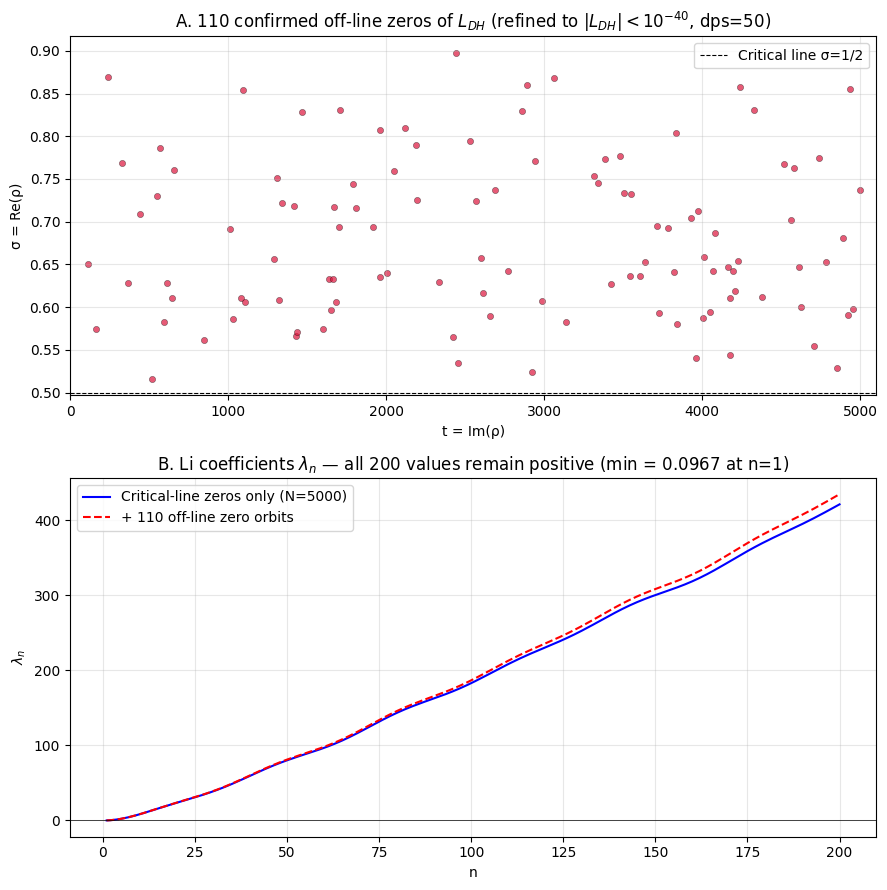

Saved final figure.


In [24]:
# Final figure
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9))

# Panel A: Off-line zeros distribution
ax1.scatter(df['t'], df['sigma'], c='crimson', s=20, alpha=0.7, edgecolors='black', linewidths=0.3)
ax1.axhline(0.5, color='black', linestyle='--', linewidth=0.8, label='Critical line σ=1/2')
ax1.set_xlabel('t = Im(ρ)')
ax1.set_ylabel('σ = Re(ρ)')
ax1.set_title(f'A. {len(df)} confirmed off-line zeros of $L_{{DH}}$ (refined to $|L_{{DH}}|<10^{{-40}}$, dps=50)')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 5100)

# Panel B: Li coefficients with and without off-line zeros
n_arr = np.arange(1, N_LI+1)
ax2.plot(n_arr, li_df['lambda_critical_only'], 'b-', lw=1.5, label='Critical-line zeros only (N=5000)')
ax2.plot(n_arr, li_df['lambda_total'], 'r--', lw=1.5, label=f'+ {len(df)} off-line zero orbits')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_xlabel('n')
ax2.set_ylabel(r'$\lambda_n$')
ax2.set_title(rf'B. Li coefficients $\lambda_n$ — all 200 values remain positive (min = {li_df["lambda_total"].min():.4f} at n=1)')
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ldh_offline_li_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved final figure.")
